In [291]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My\ Drive/Colab\ Notebooks/WignerCamp2026
    !pip install optuna --quiet
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running on Local computer


In [292]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

from artificial_dataset import ClassifierMetrics, make_anomaly_dataset
from altx import ALT as Altx

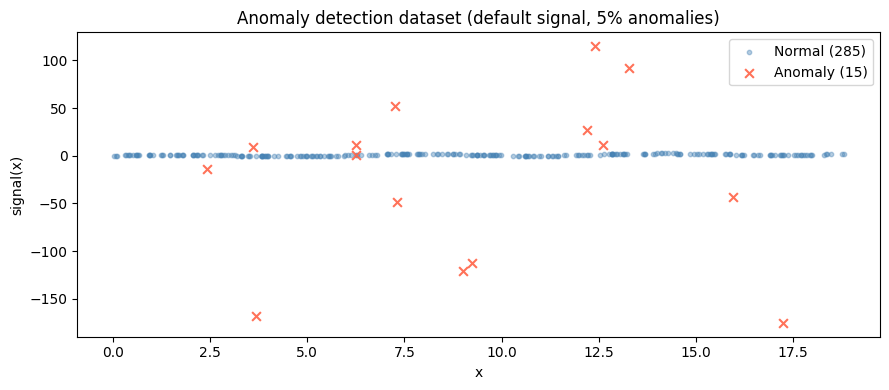

In [293]:
x, Y, labels = make_anomaly_dataset(
    n_samples=300, anomaly_fraction=0.05, random_state=0,
    anomaly_scale=1e8, noise_std=1e-6,
    x_range=(0, 6*np.pi)
)

normal = labels == 0
anomaly = labels == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x[normal],
    Y[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x[anomaly],
    Y[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

In [294]:
print(f"x:")
print(x.shape)
print(x[:5])
print(f"Y:")
print(Y.shape)
print(Y[:5])
print(f"class:")
print(labels.shape)
print(labels[:5])

x:
torch.Size([300])
tensor([0.0233, 0.0834, 0.0967, 0.3101, 0.3352])
Y:
torch.Size([300, 1])
tensor([[0.0256],
        [0.0917],
        [0.1063],
        [0.3362],
        [0.3625]])
class:
torch.Size([300])
tensor([0, 0, 0, 0, 0])


In [295]:
peaks, properties = find_peaks(Y[:, 0], prominence=0.1)
print(peaks, properties)

[ 26  41  61  63 106 109 121 138 152 155 203 206 208 225 236 262] {'prominences': array([1.13645490e+00, 8.80893042e-01, 2.30186968e+01, 3.81673843e-01,
       1.18073851e-01, 1.02633693e+01, 1.72688641e+02, 5.04846348e+01,
       1.13717998e+02, 1.01337191e+00, 2.62273059e+01, 2.83011017e+02,
       1.03452550e+01, 9.06765139e+01, 1.80653334e-01, 4.41449105e+01]), 'left_bases': array([  0,  40,  40,  62,  62,  62,  62, 123, 151, 154, 151,  62, 207,
       207, 226, 261]), 'right_bases': array([ 40,  60,  62,  81, 107, 110, 151, 151, 154, 185, 204, 280, 209,
       280, 280, 280])}


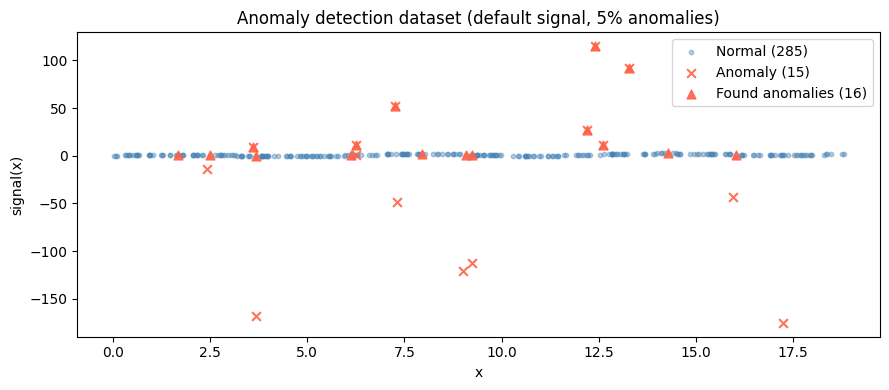

In [296]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x[normal],
    Y[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x[anomaly],
    Y[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.scatter(
    x[peaks],
    Y[peaks, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="^",
    label=f"Found anomalies ({peaks.shape[0]})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

In [297]:
y_pred = torch.zeros(labels.shape[0])
y_pred[peaks] = 1

m = ClassifierMetrics(y_true=labels, y_pred=y_pred)

print(f"Accuracy  : {m.accuracy:.3f}")
print(f"Precision : {m.precision:.3f}")
print(f"Recall    : {m.recall:.3f}")
print(f"F1 score  : {m.f1_score:.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(m.confusion_matrix)


Accuracy  : 0.943
Precision : 0.705
Recall    : 0.718
F1 score  : 0.711

Confusion matrix (rows = true, cols = predicted):
tensor([[276,   9],
        [  8,   7]])


## Transforming with `altx`

In [298]:
import torch.nn.functional as F

input_data_raw = Y.T.unsqueeze(0)

# ----- Train test split
train_test_ratio = 0.2

train_set    = input_data_raw[..., :int(train_test_ratio * input_data_raw.shape[-1])]
train_x      = x[..., :int(train_test_ratio * input_data_raw.shape[-1])]
train_labels = labels[..., :int(train_test_ratio * input_data_raw.shape[-1])]
test_set     = input_data_raw[..., int(train_test_ratio * input_data_raw.shape[-1]):]
test_x       = x[..., int(train_test_ratio * input_data_raw.shape[-1]):]
test_labels  = labels[..., int(train_test_ratio * input_data_raw.shape[-1]):]

# ----- Split train set along last dim, skipping anomaly edge indices
#train_labels = labels[:train_set.shape[-1]]
edge_indices = (train_labels == 1).nonzero(as_tuple=True)[0].tolist()

N = train_set.shape[-1]
boundaries = [-1] + edge_indices + [N]

segments = []
for e_prev, e_next in zip(boundaries[:-1], boundaries[1:]):
    start, end = e_prev + 1, e_next
    if start < end:
        segments.append(train_set[..., start:end])

# ----- Pad and stack into one tensor
pad_value = 0.0

train_lengths = torch.tensor([seg.shape[-1] for seg in segments])
max_len = train_lengths.max().item()

train_segments = torch.cat(
    [F.pad(seg, (0, max_len - seg.shape[-1]), value=pad_value) for seg in segments],
    dim=0,
)
train_classes = torch.zeros(train_segments.shape[0])

In [299]:
print(train_segments)
print(train_segments.shape)
print(train_lengths)
print(f"test_set.shape: {test_set.shape}")

tensor([[[0.0256, 0.0917, 0.1063, 0.3362, 0.3625, 0.4131, 0.4506, 0.4767,
          0.5430, 0.6227, 0.6289, 0.6475, 0.6624, 0.6983, 0.8871, 0.9029,
          0.9140, 0.9202, 0.9553, 1.0651, 1.0769, 1.0887, 1.1420, 1.1433,
          1.1613, 1.1620, 1.1621, 1.1617, 1.1566, 1.1530, 1.1527, 1.0924,
          1.0914, 1.0840, 1.0659, 1.0497, 1.0466, 1.0273, 0.9755, 0.9599]],

        [[0.8563, 0.7643, 0.6880, 0.6464, 0.6345, 0.6310, 0.5808, 0.5357,
          0.4814, 0.4096, 0.3668, 0.3199, 0.2770, 0.1857, 0.1685, 0.1625,
          0.1582, 0.0276, 0.0063, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]]])
torch.Size([2, 1, 40])
tensor([40, 19])
test_set.shape: torch.Size([1, 1, 240])


In [300]:
rlk = (None, 2, 1)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Altx(train_set=train_segments, train_classes=train_classes, train_length=train_lengths,
             R=rlk[0], L=rlk[1], K=rlk[2], device=device)
print(f"tau (instances): {model.tau}")
print(f"m (channels):    {model.m}")
print(f"noc (classes):   {model.noc}")
print(f"RLK triplets:    {model.RLK}")
print(f"class_labels:    {model.class_labels}")

model.train()
model.print_number_of_laws()

transformed_train_data = model.multiply_only(z=train_set[0, :, :], rlk=model.RLK[0], normalize_data=True)
transformed_train_x = train_x[:-model.RLK[0][1]+1]
transformed_train_labels = train_labels[:-model.RLK[0][1]+1]
print(transformed_train_data.shape)
print(transformed_train_x.shape)

transformed_test_data = model.multiply_only(z=test_set[0, :, :], rlk=model.RLK[0], normalize_data=True)
transformed_test_x = test_x[:-model.RLK[0][1]+1]
transformed_test_labels = test_labels[:-model.RLK[0][1]+1]
print(transformed_test_data.shape)
print(transformed_test_x.shape)

tau (instances): 2
m (channels):    1
noc (classes):   1
RLK triplets:    ((3, 2, 1),)
class_labels:    tensor([0.])
Number of laws for r = 3, l = 2, k = 1:
(tensor([0.]), tensor([55]))
torch.Size([59, 55, 1])
torch.Size([59])
torch.Size([239, 55, 1])
torch.Size([239])


In [301]:
transformed_test_data.shape

torch.Size([239, 55, 1])

Original: Accuracy: 0.9433, Precision: 0.7047 Recall: 0.7175, F1: 0.7109
Train:    Accuracy: 0.9500, Precision: 0.4914 Recall: 0.4831, F1: 0.4872
Test:     Accuracy: 0.8958, Precision: 0.5098 Recall: 0.5092, F1: 0.5094


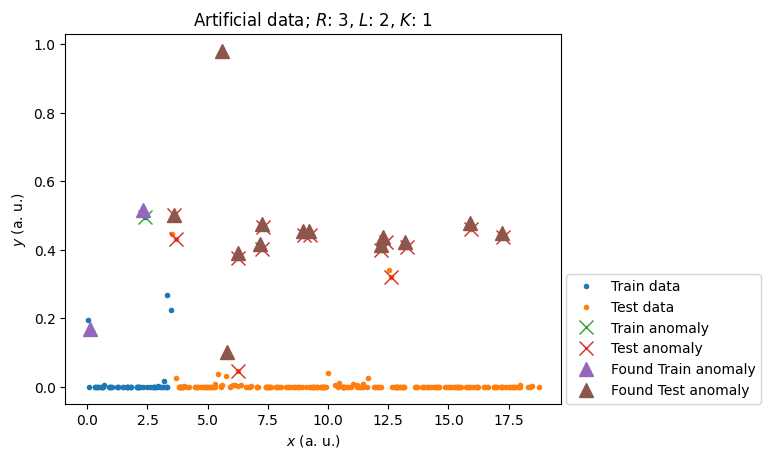

In [313]:
def compress_data(x: torch.Tensor) -> torch.Tensor:
    return torch.quantile(x**2, q=0.1, dim=1)

print(f"Original: Accuracy: {m.accuracy:.4f}, Precision: {m.precision:.4f} "
      f"Recall: {m.recall:.4f}, F1: {m.f1_score:.4f}")

train_anomaly_x = (transformed_train_labels == 1).nonzero()
test_anomaly_x = (transformed_test_labels == 1).nonzero()
train_y = compress_data(transformed_train_data[:, :, 0])
test_y = compress_data(transformed_test_data[:, :, 0])

train_peaks, _ = find_peaks(train_y, prominence=0.1)
test_peaks, _ = find_peaks(test_y, height=(0.1, 1))

y_pred_train = torch.zeros(train_labels.shape[0])
y_pred_train[train_peaks] = 1
m_train = ClassifierMetrics(y_true=train_labels, y_pred=y_pred_train)
print(f"Train:    Accuracy: {m_train.accuracy:.4f}, Precision: {m_train.precision:.4f} "
      f"Recall: {m_train.recall:.4f}, F1: {m_train.f1_score:.4f}")

y_pred_test = torch.zeros(test_labels.shape[0])
y_pred_test[test_peaks] = 1
m_test = ClassifierMetrics(y_true=test_labels, y_pred=y_pred_test)
print(f"Test:     Accuracy: {m_test.accuracy:.4f}, Precision: {m_test.precision:.4f} "
      f"Recall: {m_test.recall:.4f}, F1: {m_test.f1_score:.4f}")

plt.plot(transformed_train_x, train_y, ".", label="Train data")
plt.plot(transformed_test_x, test_y, ".", label="Test data")
plt.plot(transformed_train_x[train_anomaly_x], train_y[train_anomaly_x], "x", ms=10, label="Train anomaly")
plt.plot(transformed_test_x[test_anomaly_x], test_y[test_anomaly_x], "x", ms=10, label="Test anomaly")
plt.plot(transformed_train_x[train_peaks], train_y[train_peaks], "^", ms=10, label="Found Train anomaly")
plt.plot(transformed_test_x[test_peaks], test_y[test_peaks], "^", ms=10, label="Found Test anomaly")
plt.legend(loc=(1.01, 0))
plt.xlabel("$x$ (a. u.)")
plt.ylabel("$y$ (a. u.)")
plt.title(f"Artificial data; $R$: {model.RLK[0][0]}, $L$: {model.RLK[0][1]}, $K$: {model.RLK[0][2]}");


# Questions

- Do we split the train set to instances at the anomalies? If yes, how do we deal with too short instances?
- How do we model anomalies:
    - Distinct points?
    - When the trend changes?
    - Ranges of anomalous data?